In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

lattice_size = 100
T = 273 # K
kB = 1.380649e-23 # J/K


beta = 1/kB*T
lattice = np.random.random((lattice_size, lattice_size))
lattice = np.where(lattice>0.5, 1, -1).astype(int)

@njit
def getEnergy(lattice, J = 1):
    LatShiftedUp = np.roll(lattice, shift=-1, axis=0) # roll ya hace wrap
    LatShiftedRight = np.roll(lattice, shift=1, axis=1)

    UpEnergyMat = lattice*LatShiftedUp
    RightEnergyMat = lattice*LatShiftedRight

    Einit = -1*J*(np.sum(UpEnergyMat)+np.sum(RightEnergyMat))

    return Einit
@njit
def FlipRandSpin(lattice, Einit):
    LatLen = lattice.shape[0]
    RandIdx_i, RandIdx_j = np.random.uniform(0, LatLen, 2).astype(int)

    # si está en el borde hay que tener en cuenta frontera periódica
    #print(lattice.shape)
    PaddedLat = np.pad(lattice, pad_width=((1, 1), (1, 1)), mode = 'wrap')
    RandIdx_i, RandIdx_j = RandIdx_i + 1, RandIdx_j + 1
    @njit
    def LocalE(lattice, idx_i, idx_j):
        MiniLat = lattice[idx_i-1:idx_i+2, idx_j-1:idx_j+2].copy()# matriz 3x3
        MiniLat[0][0] = MiniLat[0][-1] = MiniLat[-1][0] = MiniLat[-1][-1] = 0 # anulamos esquinas
        MiniLat = np.pad(MiniLat, pad_width=((1, 1), (1, 1)), mode = 'constant', constant_values=0) # pad de ceros para no contar energía extra
        
        return getEnergy(MiniLat) # energia de la region local del spin seleccionado
    
    EinitLocal = LocalE(PaddedLat, RandIdx_i, RandIdx_j) # energia sin flip

    PaddedLat[RandIdx_i][RandIdx_j] = PaddedLat[RandIdx_i][RandIdx_j]*-1 #flipeamos el spin

    EendLocal = LocalE(PaddedLat, RandIdx_i, RandIdx_j) # energia con flip

    deltaE = EendLocal-EinitLocal


    
    if deltaE>0:
        p = np.exp(-beta*deltaE)
        r = np.random.uniform(0, 1, size=1)[0]
        
        if r<=p:
            pass

        else:
            PaddedLat[RandIdx_i][RandIdx_j] = PaddedLat[RandIdx_i][RandIdx_j]*-1 #dejamos como estaba
            ReturnLattice = PaddedLat[1:-1, 1:-1] # quitar padding
            ReturnEnergy = Einit

    else:
        ReturnLattice = PaddedLat[1:-1, 1:-1]# quitar padding
        ReturnEnergy = Einit+deltaE
    
    return ReturnLattice, ReturnEnergy

steps = 100000
Einit = getEnergy(lattice)

iter_list = []
lattice_list = []
Einit_list = []

for i in range(0, steps, 1):
    lattice, Einit = FlipRandSpin(lattice, Einit)
    lattice_list.append(lattice)
    Einit_list.append(Einit)
    iter_list.append(i)
    print(f'Iteration {i}/{steps}', flush=True)

plt.figure(figsize=(4, 5))
plt.plot(iter_list, Einit_list)
plt.show()

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1m[1mNo implementation of function Function(<function roll at 0x0000014F7E26CE00>) found for signature:
 
 >>> roll(array(int64, 2d, C), shift=Literal[int](-1), axis=Literal[int](0))
 
There are 2 candidate implementations:
[1m - Of which 2 did not match due to:
 Overload in function 'np_roll': File: numba\np\arraymath.py: Line 2355.
   With argument(s): '(array(int64, 2d, C), shift=int64, axis=int64)':[0m
[1m  Rejected as the implementation raised a specific error:
    TypingError: [1mgot an unexpected keyword argument 'axis'[0m[0m
  raised from c:\Users\ammun\Desktop\coding_projects\Local_projects\Computational_Physics\.venv\Lib\site-packages\numba\core\typing\templates.py:791
[0m
[0m[1mDuring: resolving callee type: Function(<function roll at 0x0000014F7E26CE00>)[0m
[0m[1mDuring: typing of call at C:\Users\ammun\AppData\Local\Temp\ipykernel_20000\1392346421.py (16)[0m
[1m
File "..\..\..\

MovieWriter imagemagick unavailable; using Pillow instead.


GIF guardado: ising_lattice_matplot.gif


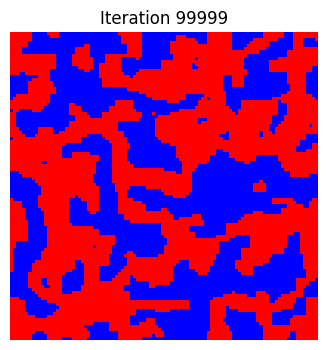

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ------------------------------------------------------------------
# 1️⃣  Configura la figura y la primera imagen
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_axis_off()                       # sin ejes
im = ax.imshow(lattice_list[0], cmap='bwr',
               vmin=-1, vmax=1, origin='lower',
               interpolation='nearest')
ax.set_title('Iteration 0')

# ------------------------------------------------------------------
# 2️⃣  Función de actualización
# ------------------------------------------------------------------
def update(frame):
    im.set_data(lattice_list[frame])
    ax.set_title(f'Iteration {frame}')
    return [im]

# ------------------------------------------------------------------
# 3️⃣  Crea la animación
# ------------------------------------------------------------------
ani = animation.FuncAnimation(fig, update,
                              frames=len(lattice_list),
                              interval=0,    # 100 ms por cuadro
                              blit=True,
                              repeat=False)

# ------------------------------------------------------------------
# 4️⃣  Guarda como GIF (requiere ImageMagick en el PATH)
# ------------------------------------------------------------------
ani.save('ising_lattice_matplot.gif', writer='imagemagick', fps=100)

print('GIF guardado: ising_lattice_matplot.gif')
